In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as scp
from scipy.cluster.hierarchy import linkage, dendrogram
import statsmodels.api as sm
import statsmodels.stats.multitest as multi
from matplotlib.pyplot import FormatStrFormatter
import matplotlib.patches as mpatches
# # Toggle as needed
import warnings
warnings.filterwarnings("ignore")
import sys
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.processing.postprocessing import post_masking

In [3]:
#Logistic Regression Model
def response_rate_logit(x,y):
    log_reg = sm.Logit(y,sm.add_constant(x)).fit(method='lbfgs',maxiter=99999,disp=0)
    return log_reg.pvalues,log_reg.params

results_by_dataset = {}
myleoid_cells = {}

In [4]:
dataset = 'original_data'
un_mask_su2c_clinical = pd.read_csv(f'../NSCLC/Data/{dataset}.csv').iloc[:,0:29]
su2c_clinical = post_masking(un_mask_su2c_clinical)
su2c_clinical = su2c_clinical.rename(columns= {
    'Patient_ID': 'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'
})
su2c_clinical['Harmonized_Confirmed_BOR_Bin'] = su2c_clinical['Harmonized_Confirmed_BOR_3_Cat'].map({
    'PR/CR': 1, 'CR/PR': 1, 'PR': 1, 'CR': 1,
    'SD': 0, 'PD': 0
})

In [5]:
dataset = 'Origin'
su2c_is_sf_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/SF_{dataset}.csv')
su2c_is_sf_harm = su2c_is_sf_harm.rename(columns = {'Patient_ID':
                                                   'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})

su2c_is_zi_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/ZI_{dataset}.csv')
su2c_is_zi_harm = su2c_is_zi_harm.rename(columns = {'Patient_ID':
                                                   'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})

su2c_is_hm_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/Other_{dataset}.csv')
su2c_is_hm_harm = su2c_is_hm_harm.rename(columns = {'Patient_ID':
                                                   'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
# su2c_is_sf_harm.head()

In [6]:
su2c_merge_master = su2c_clinical.merge(su2c_is_hm_harm.rename(columns = lambda x: x + '_HM'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',axis=1)\
    .merge(su2c_is_sf_harm.rename(columns = lambda x: x + '_SF'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',axis=1)\
    .merge(su2c_is_zi_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)

In [7]:
select_cols = ['B-cells_SF',
 'Cytotoxic cells_SF',
 'DC_SF',
 'Exhausted CD8_SF',
 'Exhausted/HS CD8_SF',
 'Lymphocytes_SF',
 'Lymphocytes exhausted/cell cycle_SF',
 'Macrophages/Monocytes_SF',
 'Memory T cells_SF',
 'Plasma_SF',
 'Treg_SF']
ZI_cells = [
    'hMø1_ZI', 'hMø4_ZI', 'hMø5_ZI', 'hMø6_ZI', 'hMø7_ZI', 'hMø8_ZI','hMø9_ZI', 'hMono1_ZI','hMono2_ZI', 'hMono3_ZI',
    'hN1_ZI',  'hN2_ZI', 'hN3_ZI',  'hN5_ZI', 'hDC1_ZI', 'hDC2_ZI', 'hDC3_ZI','hpDC_ZI']

In [8]:
log_reg = []
df = pd.DataFrame()
df_test = su2c_merge_master
for feature in select_cols:
    X = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2').loc[:,[feature]]
    if X.iloc[:,0].dtype.name!='float64':
        Xd = pd.get_dummies(X,dummy_na=True).iloc[:,0:-1]
        df = pd.concat([df,Xd],axis=1)
        for col in Xd.columns:
            y = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2')['Harmonized_Confirmed_BOR_Bin']
            Xi = Xd[[col]]
            Xy = Xi.merge(y,left_index=True,right_index=True,how='inner').dropna()
            Xi = Xy.iloc[:,[0]]
            y = Xy.iloc[:,[1]]
            p, param = response_rate_logit(Xi,y)
            log_reg.append([Xi.columns[0],p[1],param[1]])
    else:
        df = pd.concat([df,X],axis=1)
        y = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2')['Harmonized_Confirmed_BOR_Bin']
        Xy = X.merge(y,left_index=True,right_index=True,how='inner').dropna()
        X = Xy.iloc[:,[0]]
        y = Xy.iloc[:,[1]]
        p, param = response_rate_logit(X,y)
        log_reg.append([feature,p[1],param[1]])
log_reg_df = pd.DataFrame(log_reg,columns=['Feature','p_value','coeff']).set_index('Feature')

In [259]:
log_reg_zi = []
df = pd.DataFrame()
df_test = su2c_merge_master
for feature in ZI_cells:
    X = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2').loc[:,[feature]]
    if X.iloc[:,0].dtype.name!='float64':
        Xd = pd.get_dummies(X,dummy_na=True).iloc[:,0:-1]
        df = pd.concat([df,Xd],axis=1)
        for col in Xd.columns:
            y = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2')['Harmonized_Confirmed_BOR_Bin']
            Xi = Xd[[col]]
            Xy = Xi.merge(y,left_index=True,right_index=True,how='inner').dropna()
            Xi = Xy.iloc[:,[0]]
            y = Xy.iloc[:,[1]]
            p, param = response_rate_logit(Xi,y)
            log_reg.append([Xi.columns[0],p[1],param[1]])
    else:
        df = pd.concat([df,X],axis=1)
        y = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2')['Harmonized_Confirmed_BOR_Bin']
        Xy = X.merge(y,left_index=True,right_index=True,how='inner').dropna()
        X = Xy.iloc[:,[0]]
        y = Xy.iloc[:,[1]]
        p, param = response_rate_logit(X,y)
        log_reg_zi.append([feature,p[1],param[1]])
log_reg_zi_df = pd.DataFrame(log_reg_zi,columns=['Feature','p_value','coeff']).set_index('Feature')

In [260]:
myleoid_cells['Origin']=log_reg_zi_df

In [174]:
results_by_dataset['TVAE'] = log_reg_df

In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle


# Colorblind-safe (Okabe-Ito) suggestion for manuscript-level plots
PAL_ASSOC = {
    "Response": "#0072B2",      # blue
    "Progressor": "#D55E00",    # vermillion
}

DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}


def build_signed_log10p_long_df(
    results_by_dataset: dict,
    features_order=None,
    dataset_order=None,
) -> pd.DataFrame:
    """
    Build a long-format DataFrame containing signed -log10(p-value) per feature and dataset.

    Args:
        results_by_dataset (dict): Mapping dataset name -> logistic regression result DataFrame
            indexed by Feature and containing columns ['p_value', 'coeff'].
        features_order (list | None): Optional ordering of features for plotting.
        dataset_order (list | None): Optional ordering of datasets for plotting.

    Returns:
        pd.DataFrame: Long-format table with columns:
            ['Dataset', 'Feature', 'p_value', 'coeff', 'SignedLog10P', 'PalAssoc'].

    Raises:
        ValueError: If required columns are missing in any dataset DataFrame.
    """
    required_cols = {"p_value", "coeff"}

    rows = []
    for dataset_name, df in results_by_dataset.items():
        if not required_cols.issubset(set(df.columns)):
            missing = required_cols - set(df.columns)
            raise ValueError(
                f"Dataset '{dataset_name}' is missing required columns: {missing}"
            )

        tmp = df.copy()
        tmp = tmp.reset_index().rename(columns={"index": "Feature"})
        tmp["Dataset"] = dataset_name

        tmp["SignedLog10P"] = -np.log10(tmp["p_value"].astype(float)) * np.sign(
            tmp["coeff"].astype(float)
        )
        tmp["PalAssoc"] = np.where(tmp["coeff"] >= 0, "Response", "Progressor")

        rows.append(
            tmp[["Dataset", "Feature", "p_value", "coeff", "SignedLog10P", "PalAssoc"]]
        )

    out = pd.concat(rows, ignore_index=True)

    if dataset_order is not None:
        out["Dataset"] = pd.Categorical(
            out["Dataset"], categories=dataset_order, ordered=True
        )

    if features_order is not None:
        out["Feature"] = pd.Categorical(
            out["Feature"], categories=features_order, ordered=True
        )

    return out


def plot_signed_log10p_origin_vs_synthetic(
    long_df: pd.DataFrame,
    dataset_order: list,
    figsize: tuple = (18, 6),
    strip_height: float = 0.012,
    strip_y: float = 1.01,
    p_thresholds: tuple = (0.05, 0.25),
    sort_features_by: str = "origin",  # "origin" | "global_mean" | "per_dataset"
    origin_name: str = "Origin",
    share_x_axis: bool = True,
    symmetric_x_axis: bool = True,
    x_padding_ratio: float = 0.05,
    savepath=None,
) -> plt.Figure:
    """
    Plot signed -log10(p-value) comparison across Origin vs synthetic datasets with dataset color strips.

    Args:
        long_df (pd.DataFrame): Output from build_signed_log10p_long_df().
            Must contain ['Dataset', 'Feature', 'SignedLog10P', 'PalAssoc'].
        dataset_order (list): Datasets order to display as columns.
        figsize (tuple): Figure size.
        strip_height (float): Height of the colored strip under each dataset title (axes fraction).
        strip_y (float): Vertical position of the strip (axes fraction).
        p_thresholds (tuple): P-value thresholds to draw symmetric vertical lines at ±(-log10(p)).
        sort_features_by (str): Sorting strategy for y-axis feature order.
            - "origin": sort by SignedLog10P in the Origin dataset (recommended for comparison).
            - "global_mean": sort by mean SignedLog10P across all datasets.
            - "per_dataset": each subplot sorts features independently (NOT sharey-friendly).
        origin_name (str): Dataset name used when sort_features_by="origin".
        share_x_axis (bool): If True, enforce same x-limits for all subplots.
        symmetric_x_axis (bool): If True and share_x_axis=True, make x-limits symmetric around 0.
        x_padding_ratio (float): Padding ratio added to computed x-limits (e.g., 0.05 => +5%).
        savepath (str | None): If provided, path to save figure.

    Returns:
        matplotlib.figure.Figure: Matplotlib figure.

    Raises:
        ValueError: If required columns are missing or sorting option invalid.
    """
    required_cols = {"Dataset", "Feature", "SignedLog10P", "PalAssoc"}
    if not required_cols.issubset(set(long_df.columns)):
        missing = required_cols - set(long_df.columns)
        raise ValueError(f"Input long_df is missing required columns: {missing}")

    plot_df = long_df.copy()
    plot_df["Dataset"] = pd.Categorical(
        plot_df["Dataset"], categories=dataset_order, ordered=True
    )

    # ---- Feature ordering (descending SignedLog10P) ----
    if sort_features_by == "origin":
        if origin_name not in plot_df["Dataset"].cat.categories:
            raise ValueError(
                f"origin_name='{origin_name}' not found in dataset_order/categories."
            )
        origin_df = plot_df[plot_df["Dataset"] == origin_name].copy()
        feat_order = (
            origin_df.dropna(subset=["SignedLog10P"])
            .sort_values("SignedLog10P", ascending=False)["Feature"]
            .astype(str)
            .tolist()
        )
        all_feats = plot_df["Feature"].astype(str).unique().tolist()
        missing = [f for f in all_feats if f not in feat_order]
        feat_order = feat_order + sorted(missing)

    elif sort_features_by == "global_mean":
        feat_order = (
            plot_df.groupby("Feature")["SignedLog10P"]
            .mean()
            .sort_values(ascending=False)
            .index.astype(str)
            .tolist()
        )

    elif sort_features_by == "per_dataset":
        feat_order = None
    else:
        raise ValueError(
            "sort_features_by must be one of: 'origin', 'global_mean', 'per_dataset'."
        )

    if feat_order is not None:
        plot_df["Feature"] = pd.Categorical(
            plot_df["Feature"].astype(str),
            categories=feat_order,
            ordered=True,
        )

    # ---- Global x-limits (shared across panels) ----
    x_min = float(plot_df["SignedLog10P"].min(skipna=True))
    x_max = float(plot_df["SignedLog10P"].max(skipna=True))

    if share_x_axis:
        if symmetric_x_axis:
            max_abs = max(abs(x_min), abs(x_max))
            max_abs = max_abs * (1.0 + x_padding_ratio)
            global_xlim = (-max_abs, max_abs)
        else:
            span = x_max - x_min
            pad = span * x_padding_ratio
            global_xlim = (x_min - pad, x_max + pad)
    else:
        global_xlim = None

    # Precompute threshold x positions
    thr_vals = {}
    for p in p_thresholds:
        if p <= 0 or p >= 1:
            raise ValueError(f"Invalid p-value threshold: {p}. Must be in (0, 1).")
        thr_vals[p] = -np.log10(p)

    ncols = len(dataset_order)
    fig, axes = plt.subplots(
        1,
        ncols,
        figsize=figsize,
        sharey=(sort_features_by != "per_dataset"),
        gridspec_kw={"wspace": 0.15},
    )
    if ncols == 1:
        axes = [axes]

    for col_idx, dataset in enumerate(dataset_order):
        ax = axes[col_idx]

        sub = plot_df[plot_df["Dataset"] == dataset].dropna(subset=["SignedLog10P"]).copy()
        if sort_features_by == "per_dataset":
            sub = sub.sort_values("SignedLog10P", ascending=False)

        sns.barplot(
            ax=ax,
            data=sub,
            y="Feature",
            x="SignedLog10P",
            hue="PalAssoc",
            dodge=False,
            palette=PAL_ASSOC,
            hue_order=["Response", "Progressor"],
            orient="h",
            order=None if sort_features_by == "per_dataset" else feat_order,
        )

        # Apply shared x-axis limits
        if global_xlim is not None:
            ax.set_xlim(*global_xlim)

        # Center line (0)
        ax.axvline(0, color="black", linewidth=1)

        # Threshold lines (symmetric)
        if 0.05 in thr_vals:
            x = thr_vals[0.05]
            ax.axvline(x=+x, linewidth=1, linestyle="-", c="red")
            ax.axvline(x=-x, linewidth=1, linestyle="-", c="red")
        if 0.25 in thr_vals:
            x = thr_vals[0.25]
            ax.axvline(x=+x, linewidth=1, linestyle="--", c="purple")
            ax.axvline(x=-x, linewidth=1, linestyle="--", c="purple")

        ax.set_title(dataset, fontsize=12, fontweight="bold", pad=16)
        ax.set_xlabel(r"Signed $\log_{10}(p\mathrm{-value})$", fontsize=11)
        ax.set_ylabel("" if col_idx > 0 else "")

        # Dataset colored strip
        dataset_color = DATASET_COLORS.get(dataset, "#cccccc")
        ax.add_patch(
            Rectangle(
                (0, strip_y),
                1,
                strip_height,
                transform=ax.transAxes,
                facecolor=dataset_color,
                edgecolor="none",
                clip_on=False,
                zorder=10,
            )
        )

        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        ax.tick_params(axis="y", labelsize=10)
        ax.tick_params(axis="x", labelsize=10)

    # Global legend
    handles = [Rectangle((0, 0), 1, 1, fc=PAL_ASSOC[k]) for k in ["Response", "Progressor"]]
    fig.legend(
        handles=handles,
        labels=["Response", "Progressor"],
        loc="center left",
        bbox_to_anchor=(0.92, 0.5),
        title="Association",
        frameon=True,
        fontsize=11,
        title_fontsize=12,
    )

    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight", facecolor="white")

    return fig

In [184]:
def strip_feature_suffix_in_results(
    results_by_dataset: dict,
    suffix: str = "_SF",
    only_if_suffix: bool = True,
) -> dict:
    out = {}
    for ds, df in results_by_dataset.items():
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Value for dataset '{ds}' is not a pandas DataFrame: {type(df)}")

        new_df = df.copy()
        idx = new_df.index.astype(str)

        if only_if_suffix:
            new_df.index = idx.str.replace(f"{suffix}$", "", regex=True)
        else:
            new_df.index = idx.str.replace(suffix, "", regex=False)

        out[ds] = new_df

    return out
    
results_by_dataset_no_sf = strip_feature_suffix_in_results(results_by_dataset, suffix="_SF")

# Check
print(list(results_by_dataset_no_sf.values())[0].index[:10])

Index(['B-cells', 'Cytotoxic cells', 'DC', 'Exhausted CD8', 'Exhausted/HS CD8',
       'Lymphocytes', 'Lymphocytes exhausted/cell cycle',
       'Macrophages/Monocytes', 'Memory T cells', 'Plasma'],
      dtype='object', name='Feature')


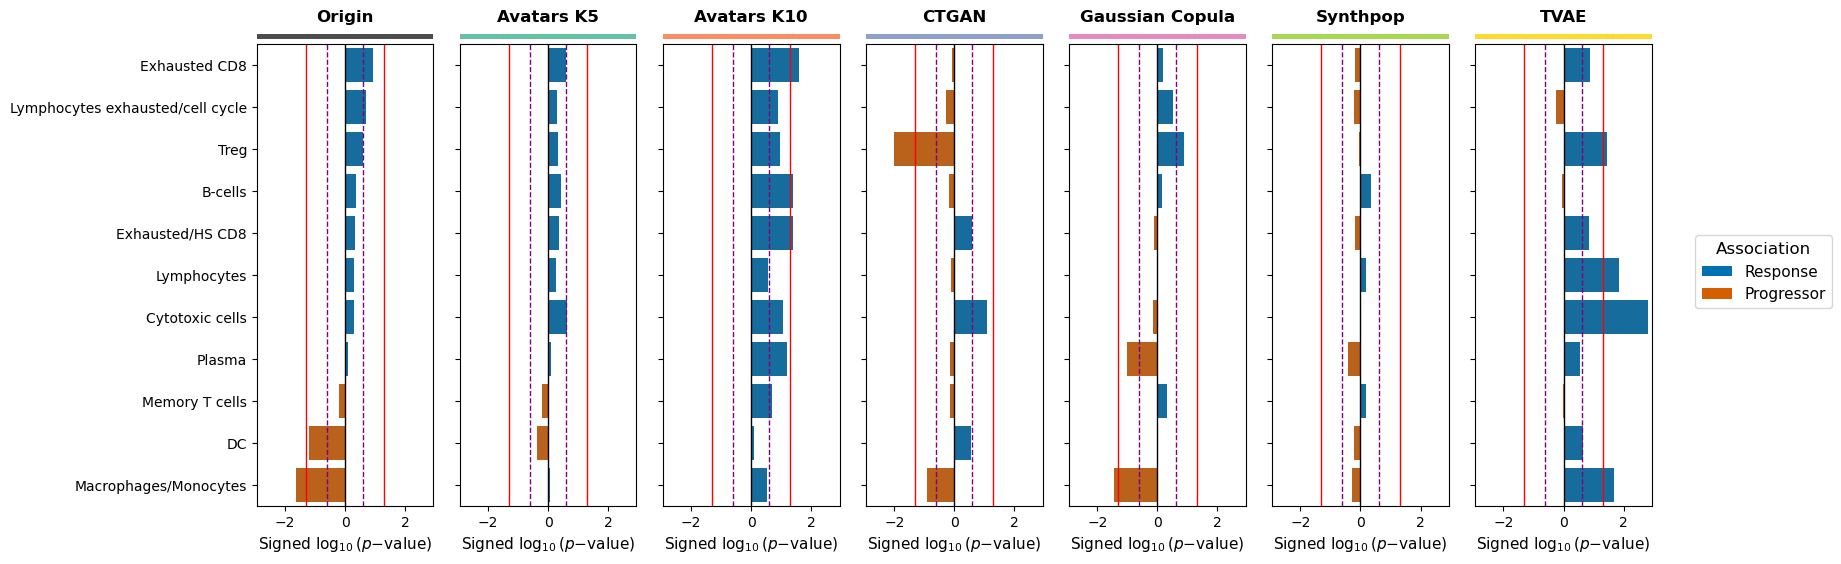

In [265]:
dataset_order = ["Origin", "Avatars K5", 'Avatars K10','CTGAN',"Gaussian Copula", "Synthpop",'TVAE']

long_df = build_signed_log10p_long_df(
    results_by_dataset=results_by_dataset_no_sf,
    dataset_order=dataset_order,
)

fig = plot_signed_log10p_origin_vs_synthetic(
    long_df=long_df,
    dataset_order=dataset_order,
    figsize=(18, 6),
    sort_features_by = 'origin',
    savepath=None
)
fig.savefig(
    "SF_LogisticRegression.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
fig.savefig(
    "SF_LogisticRegression.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

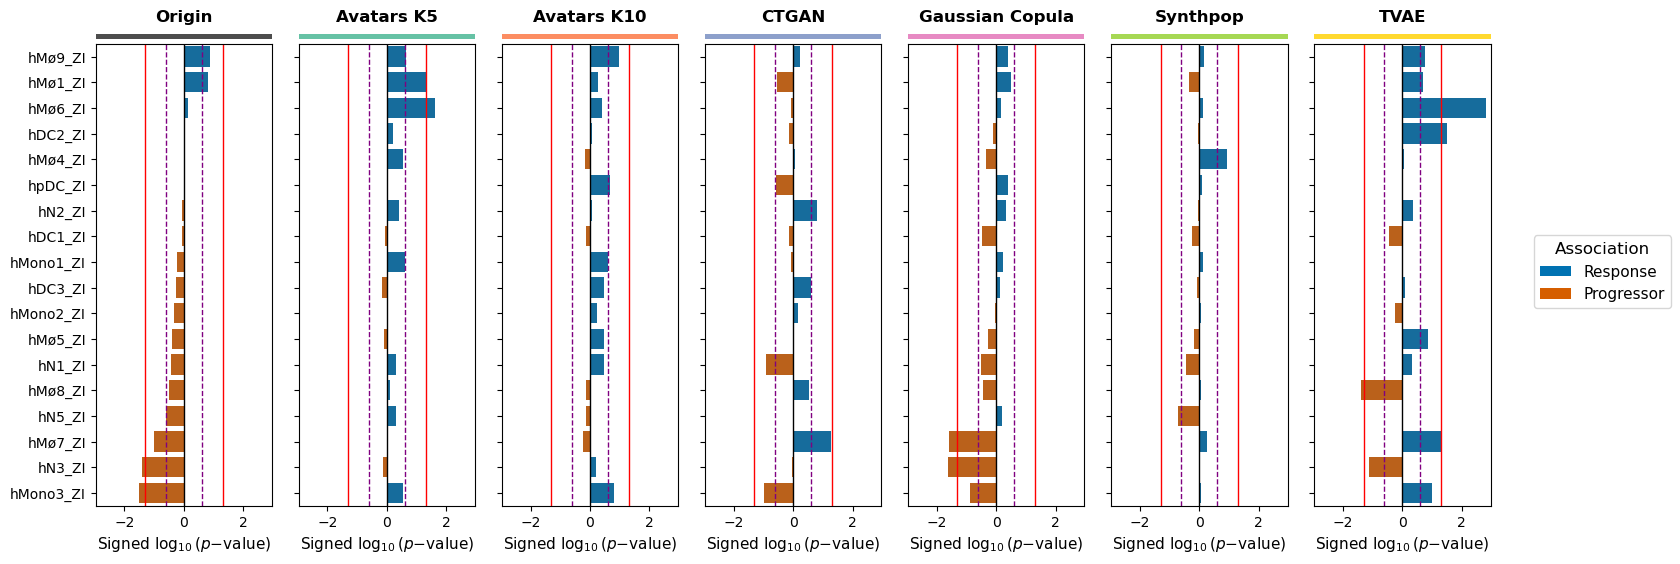

In [266]:
dataset_order = ["Origin", "Avatars K5", 'Avatars K10','CTGAN',"Gaussian Copula", "Synthpop",'TVAE']

long_df = build_signed_log10p_long_df(
    results_by_dataset=myleoid_cells,
    dataset_order=dataset_order,
)

fig_zi = plot_signed_log10p_origin_vs_synthetic(
    long_df=long_df,
    dataset_order=dataset_order,
    figsize=(18, 6),
    sort_features_by = 'origin',
    savepath=None
)
fig_zi.savefig(
    "ZI_LogisticRegression.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
fig_zi.savefig(
    "ZI_LogisticRegression.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)